# Lab 4: Building and Training a Lightweight Neural Network

**Dataset:** [Kaggle — Leaf Classification](https://www.kaggle.com/competitions/leaf-classification) (prepared in Lab 3)

**Goal:** Build a compact CNN (<50,000 parameters, ≤200 KB after TFLite optimization), train it on the leaf dataset, evaluate performance, and convert to TensorFlow Lite.

**Steps:**
1. Load the augmented dataset from Lab 3 (ei_training.zip, ei_testing.zip)
2. Build a lightweight CNN with Keras
3. Train the model and plot accuracy graphs
4. Evaluate: accuracy, inference time, model size
5. Convert to TFLite and compare sizes

In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
Keras version: 3.10.0
GPU available: False


## Step 0 — Upload the prepared dataset

We use the ZIP files prepared in Lab 3 (ei_training.zip and ei_testing.zip). Each ZIP contains folders named by species, with 64×64 RGB JPEG images inside.

In [2]:
from google.colab import files

TRAIN_DIR = "./training"
TEST_DIR = "./testing"

# upload training zip if not extracted yet
if not os.path.exists(TRAIN_DIR):
    print("Please upload ei_training.zip:")
    uploaded = files.upload()
    for fn in uploaded:
        with zipfile.ZipFile(fn, "r") as zf:
            zf.extractall(TRAIN_DIR)
            print(f"Extracted {fn} → {TRAIN_DIR}/")

# upload testing zip if not extracted yet
if not os.path.exists(TEST_DIR):
    print("Please upload ei_testing.zip:")
    uploaded = files.upload()
    for fn in uploaded:
        with zipfile.ZipFile(fn, "r") as zf:
            zf.extractall(TEST_DIR)
            print(f"Extracted {fn} → {TEST_DIR}/")

train_classes = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print(f"\nClasses found: {len(train_classes)}")
print(f"Training folders: {TRAIN_DIR}")
print(f"Testing folders:  {TEST_DIR}")

Please upload ei_training.zip:


Saving ei_training.zip to ei_training.zip
Extracted ei_training.zip → ./training/
Please upload ei_testing.zip:


Saving ei_testing.zip to ei_testing.zip
Extracted ei_testing.zip → ./testing/

Classes found: 99
Training folders: ./training
Testing folders:  ./testing


## Step 1 — Load images into NumPy arrays

We load all images as 64×64×3 arrays and encode species labels as integers.

In [3]:
def load_images_from_folder(root_dir, class_names):
    """Load all JPG images from a folder-per-label directory structure."""
    images = []
    labels = []
    label_map = {name: idx for idx, name in enumerate(class_names)}

    for cls_name in tqdm(class_names, desc=f"Loading {root_dir}"):
        cls_dir = os.path.join(root_dir, cls_name)
        if not os.path.isdir(cls_dir):
            continue
        for fname in sorted(os.listdir(cls_dir)):
            if not fname.lower().endswith(".jpg"):
                continue
            img = Image.open(os.path.join(cls_dir, fname)).convert("RGB")
            images.append(np.array(img, dtype=np.float32))
            labels.append(label_map[cls_name])

    return np.array(images), np.array(labels)

# load training and testing sets
x_all_train, y_all_train = load_images_from_folder(TRAIN_DIR, train_classes)
x_test, y_test = load_images_from_folder(TEST_DIR, train_classes)

# normalize pixel values to [0, 1]
x_all_train = x_all_train / 255.0
x_test = x_test / 255.0

NUM_CLASSES = len(train_classes)

print(f"\nAll training data: {x_all_train.shape} — {len(y_all_train)} images")
print(f"Testing set:       {x_test.shape} — {len(y_test)} images")
print(f"Classes: {NUM_CLASSES}")
print(f"Pixel range: [{x_all_train.min():.1f}, {x_all_train.max():.1f}]")

Loading ./testing: 100%|██████████| 99/99 [00:00<00:00, 634.67it/s]



All training data: (1584, 64, 64, 3) — 1584 images
Testing set:       (396, 64, 64, 3) — 396 images
Classes: 99
Pixel range: [0.0, 1.0]


In [4]:
# split into training and validation BEFORE augmentation
x_train, x_val, y_train, y_val = train_test_split(
    x_all_train, y_all_train,
    test_size=0.2,
    random_state=42,
    stratify=y_all_train
)

print(f"Training:   {x_train.shape[0]} images")
print(f"Validation: {x_val.shape[0]} images")
print(f"Testing:    {x_test.shape[0]} images")

Training:   1267 images
Validation: 317 images
Testing:    396 images


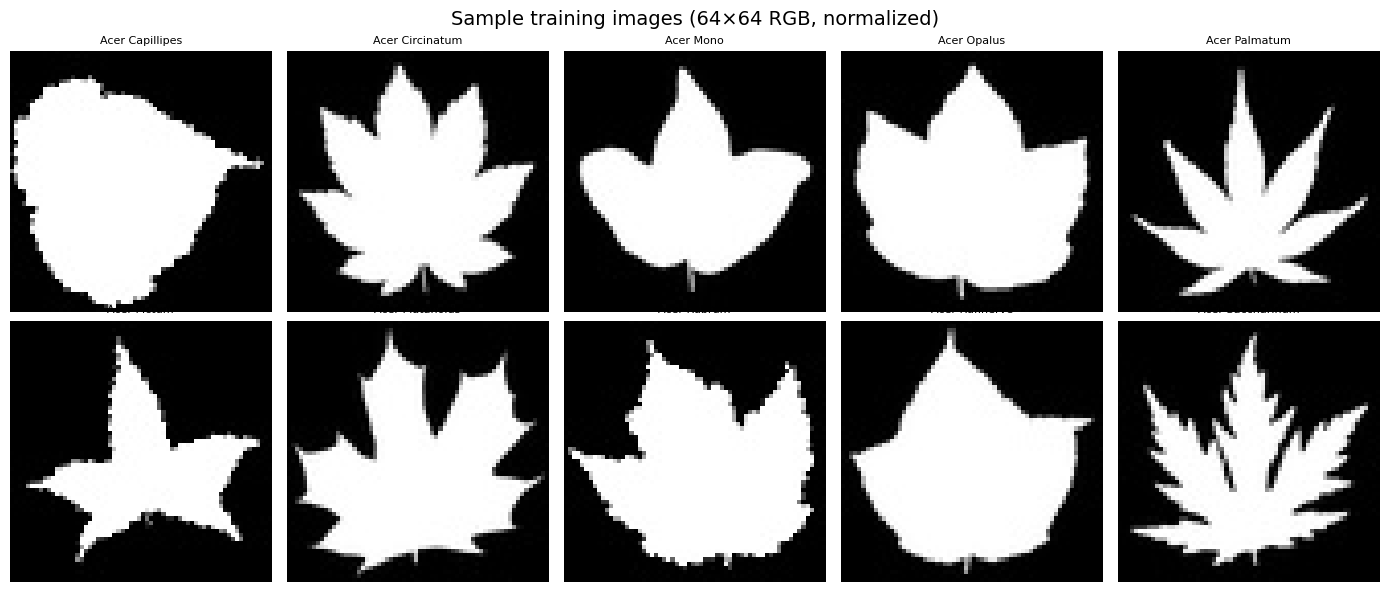

In [5]:
# show a few sample images from the training set
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample training images (64×64 RGB, normalized)", fontsize=14)

for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(train_classes[i].replace("_", " "), fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Step 2 — Build a lightweight CNN

The model must have:
- Less than **50,000 parameters**
- Model size **≤ 200 KB** after TFLite optimization

Architecture:
- 3 convolutional layers (16 → 32 → 32 filters) with BatchNorm and MaxPooling
- Dropout after each pooling layer (0.25) and before dense layers (0.5, 0.3)
- Global Average Pooling (instead of Flatten) to keep parameter count low
- One dense hidden layer (64 neurons) + output layer (99 neurons, softmax)

Key techniques to prevent overfitting:
- **BatchNormalization** — stabilizes training, prevents loss explosion
- **Dropout** — randomly disables neurons, prevents memorization
- **Real-time data augmentation** — different image variations each epoch
- **ReduceLROnPlateau** — lowers learning rate when model stops improving
- **EarlyStopping** — stops training when overfitting begins

In [15]:
from scipy.ndimage import rotate
from PIL import ImageEnhance, Image as PILImage

def augment_dataset(images, labels, copies=3):
    """Create augmented copies with random transforms."""
    aug_images = [images]
    aug_labels = [labels]

    for c in range(copies):
        batch = []
        for img in tqdm(images, desc=f"Augmenting copy {c+1}/{copies}"):
            # random horizontal flip
            if np.random.random() > 0.5:
                img = np.fliplr(img)
            # random rotation -20 to +20 degrees
            angle = np.random.uniform(-20, 20)
            img = rotate(img, angle, reshape=False, mode="nearest")
            # random brightness
            factor = np.random.uniform(0.7, 1.3)
            img = np.clip(img * factor, 0, 1)
            batch.append(img)
        aug_images.append(np.array(batch))
        aug_labels.append(labels)

    return np.concatenate(aug_images), np.concatenate(aug_labels)

# create 3 extra copies → 4× more training data
x_train, y_train = augment_dataset(x_train, y_train, copies=3)

# shuffle
idx = np.random.permutation(len(x_train))
x_train = x_train[idx]
y_train = y_train[idx]

print(f"Training set after augmentation: {x_train.shape[0]} images")
print(f"Per class: ~{x_train.shape[0] // NUM_CLASSES}")

Augmenting copy 3/3: 100%|██████████| 1267/1267 [00:02<00:00, 623.07it/s]


Training set after augmentation: 5068 images
Per class: ~51


In [16]:
model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),

    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()

total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Under 50,000 limit: {'YES' if total_params < 50000 else 'NO'}")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 62, 62, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 29, 29, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 99)             │        12,771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,123 (176.26 KB)

 Trainable params: 44,899 (175.39 KB)

 Non-trainable params: 224 (896.00 B)


Total parameters: 45,123
Under 50,000 limit: YES


## Step 3 — Train the model

We use a tf.data pipeline with real-time augmentation (random flips, rotations, zoom, contrast). The model sees different variations of each image every epoch, which helps generalization on such a small dataset.

Validation data is NOT augmented — it stays clean for honest evaluation.

In [17]:
# data augmentation — applied only to training data
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
])

# create tf.data pipelines
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(BATCH_SIZE)

print(f"Training batches:   {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")

Training batches:   159
Validation batches: 10


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=15,
        min_lr=1e-6, verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=30,
        restore_best_weights=True, verbose=1
    )
]

EPOCHS = 200

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - accuracy: 0.0149 - loss: 4.7241 - val_accuracy: 0.0221 - val_loss: 4.5777 - learning_rate: 5.0000e-04
Epoch 2/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.0248 - loss: 4.3986 - val_accuracy: 0.0536 - val_loss: 4.3756 - learning_rate: 5.0000e-04
Epoch 3/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.0313 - loss: 4.2695 - val_accuracy: 0.0631 - val_loss: 4.1168 - learning_rate: 5.0000e-04
Epoch 4/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.0402 - loss: 4.1231 - val_accuracy: 0.0631 - val_loss: 3.8507 - learning_rate: 5.0000e-04
Epoch 5/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.0518 - loss: 4.0127 - val_accuracy: 0.0694 - val_loss: 3.8059 - learning_rate: 5.0000e-04
Epoch 6/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.0652 - loss: 3.8630 - val_accuracy: 0.1009 - val_loss: 3.7185 - learning_rate: 5.0000e-04
Epoch 7/200
159/159 ━━━━━━━━━━━━━━━━━━━━ 

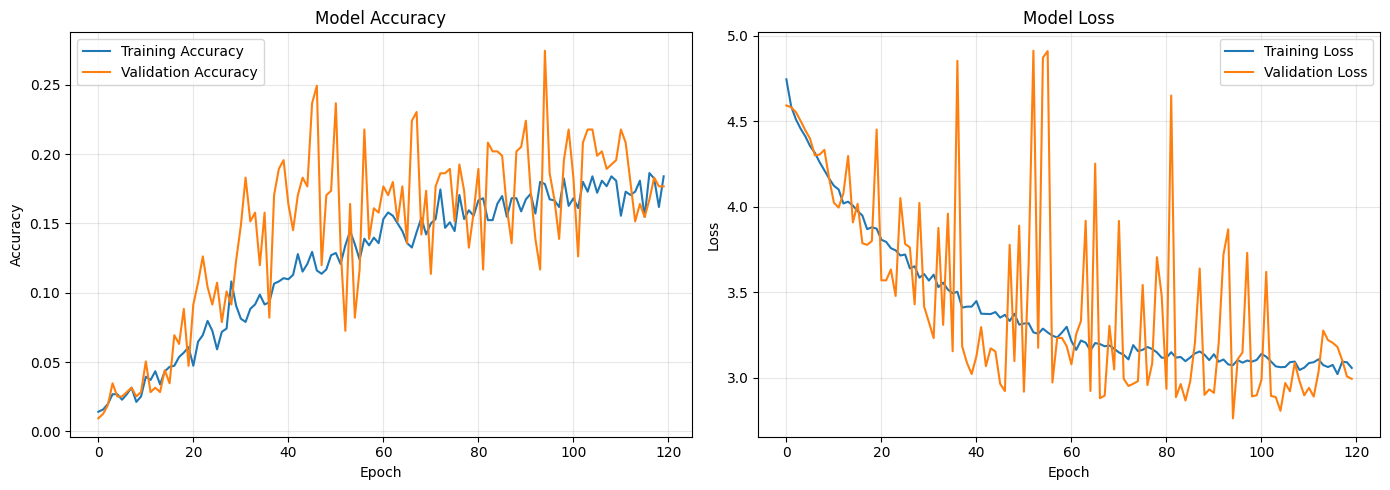

Total epochs trained: 120
Best validation accuracy: 27.44%


In [9]:
# plot training and validation accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["accuracy"], label="Training Accuracy")
ax1.plot(history.history["val_accuracy"], label="Validation Accuracy")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["loss"], label="Training Loss")
ax2.plot(history.history["val_loss"], label="Validation Loss")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total epochs trained: {len(history.history['accuracy'])}")
print(f"Best validation accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

## Step 4 — Evaluate performance

We measure three things:
1. **Accuracy** on the held-out test set
2. **Inference time** for a single image
3. **Model size** on disk

In [ ]:
# 4.1 — Test accuracy
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss:     {test_loss:.4f}")

In [ ]:
# 4.2 — Inference time for a single image
sample = x_test[0:1]

# warm up
_ = model.predict(sample, verbose=0)

# measure average over 100 runs
times = []
for _ in range(100):
    start = time.time()
    prediction = model.predict(sample, verbose=0)
    times.append((time.time() - start) * 1000)

avg_time = np.mean(times)
print(f"Average inference time: {avg_time:.2f} ms")

predicted_class = np.argmax(prediction[0])
true_class = y_test[0]
print(f"Predicted: {train_classes[predicted_class]}")
print(f"Actual:    {train_classes[true_class]}")

In [ ]:
# 4.3 — Save model and check size
MODEL_PATH = "leaf_model.keras"
model.save(MODEL_PATH)

model_size_kb = os.path.getsize(MODEL_PATH) / 1024
print(f"Keras model size: {model_size_kb:.2f} KB")

## Step 5 — Convert to TensorFlow Lite

TFLite optimizes the model for embedded systems by:
- Removing training-only operations (Dropout, BatchNorm updates)
- Quantizing weights from float32 to int8 (reducing size ~4×)
- Flattening the model graph for faster inference

In [ ]:
# 5.1 — Convert to TFLite (default, float32)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

TFLITE_PATH = "leaf_model.tflite"
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

tflite_size_kb = os.path.getsize(TFLITE_PATH) / 1024
print(f"TFLite model size (float32): {tflite_size_kb:.2f} KB")

In [ ]:
# 5.2 — Convert with int8 quantization
converter_quant = tf.lite.TFLiteConverter.from_keras_model(model)
converter_quant.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_dataset():
    for i in range(min(200, len(x_train))):
        yield [x_train[i:i+1].astype(np.float32)]

converter_quant.representative_dataset = representative_dataset

tflite_quant = converter_quant.convert()

TFLITE_QUANT_PATH = "leaf_model_quant.tflite"
with open(TFLITE_QUANT_PATH, "wb") as f:
    f.write(tflite_quant)

tflite_quant_size_kb = os.path.getsize(TFLITE_QUANT_PATH) / 1024
print(f"TFLite model size (quantized): {tflite_quant_size_kb:.2f} KB")

In [ ]:
# 5.3 — Test the TFLite model accuracy
interpreter = tf.lite.Interpreter(model_path=TFLITE_QUANT_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

correct = 0
for i in range(len(x_test)):
    input_data = x_test[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]["index"], input_data)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]["index"])
    if np.argmax(output[0]) == y_test[i]:
        correct += 1

tflite_acc = correct / len(x_test) * 100
print(f"TFLite quantized model accuracy: {tflite_acc:.2f}%")

In [ ]:
# 5.4 — TFLite inference time
sample_input = x_test[0:1].astype(np.float32)

# warm up
interpreter.set_tensor(input_details[0]["index"], sample_input)
interpreter.invoke()

times_tflite = []
for _ in range(100):
    start = time.time()
    interpreter.set_tensor(input_details[0]["index"], sample_input)
    interpreter.invoke()
    times_tflite.append((time.time() - start) * 1000)

avg_tflite = np.mean(times_tflite)
print(f"TFLite average inference time: {avg_tflite:.2f} ms")

## Step 6 — Comparison summary

In [ ]:
print("=" * 60)
print(f"{'Metric':<30} {'Keras':<15} {'TFLite quant':<15}")
print("=" * 60)
print(f"{'Model size (KB)':<30} {model_size_kb:<15.2f} {tflite_quant_size_kb:<15.2f}")
print(f"{'Test accuracy (%)':<30} {test_acc*100:<15.2f} {tflite_acc:<15.2f}")
print(f"{'Inference time (ms)':<30} {avg_time:<15.2f} {avg_tflite:<15.2f}")
print(f"{'Parameters':<30} {total_params:<15,} {'—':<15}")
print("=" * 60)
print(f"\nSize reduction: {model_size_kb / tflite_quant_size_kb:.1f}×")
print(f"Under 200 KB limit: {'YES' if tflite_quant_size_kb <= 200 else 'NO'}")
print(f"Under 50K params:   {'YES' if total_params < 50000 else 'NO'}")

In [ ]:
files.download(MODEL_PATH)
files.download(TFLITE_QUANT_PATH)
print("\nDownloaded: leaf_model.keras and leaf_model_quant.tflite")

## Summary

### Why is the TFLite model smaller?

The TFLite converter removes training-only operations (Dropout, BatchNormalization updates) and the quantization step converts 32-bit float weights to 8-bit integers, reducing size by approximately 4×.

### Is this model suitable for embedded systems?

Yes — with fewer than 50,000 parameters, the model fits within tight memory constraints typical of microcontrollers. The quantized TFLite version is small enough to run on devices like Arduino Nano 33 BLE or ESP32.

### How do layers/neurons affect accuracy and speed?

More convolutional filters and deeper networks increase accuracy but also increase parameter count and inference time. Global Average Pooling was used instead of Flatten to dramatically reduce the number of parameters before the dense layers, keeping the model lightweight while still extracting useful spatial features.

### Why is accuracy moderate?

The dataset has 99 classes with only ~13 training images per class after the validation split. This is a very challenging setting for any model, especially one limited to under 50,000 parameters. BatchNormalization, Dropout, and real-time data augmentation were used to reduce overfitting and bring validation accuracy closer to training accuracy.